In [1]:
import os

# Force GPU 1
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
# Clear GPU memory and restart clean
import torch
import gc

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd

import json
from datetime import datetime
from scipy import signal

In [2]:
from pngtojson import points_to_intensity_grid, png_to_xy_intensity

In [3]:
def load_data(folder_path):
    # Load the data from the specified folder
    data = dict()
    count =0 
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.png') and count <= 10000000:
            intensity_points = png_to_xy_intensity(os.path.join(folder_path, file_name),include_zero=True)
            intensity_grid = points_to_intensity_grid(intensity_points )
            intensity_df = pd.DataFrame(intensity_grid)
            data[file_name] = intensity_df
            count += 1
    print(f"Loaded {count} images.")
    
    return data

data = load_data("C:\\Users\\Jacobs laptop\\rainraingoaway\\data\\70km\\png")
print (len(data))

first_key, value = next(iter(data.items()))

print(f"ID {first_key}")
print(value.shape)
print(value.head())


In [4]:
#prev_key = first_key
def create_samples(data, list_length=10, min_list_length = 7):
    count = 1 
    data_grouped = list()
    sample_list= list()
    
    
    ttl_cnt = 0 
    keys = sorted(data.keys())
    prev_key = keys[0]

    for key in keys[1:]:
        value = data[key]
        value= torch.from_numpy(value.to_numpy()).float()
        ttl_cnt+=1
        key_time = datetime.strptime(str(key).strip(".png"),"%Y%m%d%H%M")
        prev_key_time = datetime.strptime(str(prev_key).strip(".png"),"%Y%m%d%H%M")
        change = key_time - prev_key_time
        change = int(change.seconds/60)
        #print(f"doing key {key}, with change {change}, cureent length is {len(sample_list)}, with count {count}")
        
    
        if change > 5: # if non continous jump, end sample
            data_grouped.append(sample_list)
            print(f"sample with lenth {len(sample_list)} created due to discontinuation in series, with change {change}")
            sample_list = list()
            sample_list.append(value)
            
            count=1
            
        elif change == 5 and count <list_length: # add value to sample if we arent at the limit
            sample_list.append(value)
            
            #print("appended")
            count += 1 
            
        elif change == 5 and count >= list_length: # shelve sample and start a new sample
            data_grouped.append(sample_list)
            print(f"sample with lenth {len(sample_list)} created")
            sample_list = list()
            sample_list.append(value)
            
            count=1
        else:
            print("FUCCCKKK YOU FOING HERE" ) # should never reach this
        
        prev_key = key # pass on key information 
        
    #removing samples too short
    filtered=list()
    for idx, item in enumerate(data_grouped):
        length = len(item)

        if length < min_list_length:
            print(f"removed sample {idx} with length {length}")
        else:
            filtered.append(item)

    data_grouped = filtered
    x=list()
    y=list()

    for i in data_grouped:
        length= len(i)
        
        #print(length)
        last = i.pop(length-1)
        length= len(i)
        x.append(i)
        y.append(last)
        
    return x,y
            
            
#x,y = create_samples(data)

In [5]:
import os
import pandas as pd
from torch.utils.data import Dataset


class radar_dataset(Dataset):
    def __init__(self, folderloc , list_length=10, min_list_length = 10):
        min_list_length = list_length
        
        self.data = load_data(folderloc)
        self.x, self.y = create_samples(self.data,  list_length=list_length, min_list_length = min_list_length)
        
        
    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        sample = self.x[idx]
        target = self.y[idx]
        
        sample = torch.stack(sample).float()
        target = torch.tensor(target, dtype=torch.float32)
        return sample, target

In [ ]:
sample_size= 5 
dataset= radar_dataset("C:\\Users\\Jacobs laptop\\rainraingoaway\\data\\70km\\png", list_length=sample_size)
split_idx = int(0.8 * len(dataset))


train_dataset = torch.utils.data.Subset(dataset, range(0, split_idx))
test_dataset = torch.utils.data.Subset(dataset, range(split_idx, len(dataset)))

In [ ]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Train batches :{len(train_loader)}")
print(f"Test batches :{len(test_loader)}")

Train samples: 176
Test samples: 45
Train batches :22
Test batches :6


In [ ]:
def train_one_epoch(epoch_index, optimizer, model, loss_fn):
    running_loss = 0 
    last_loss = 0 
    for i , data in enumerate(train_loader):
        inputs, labels= data 
        optimizer.zero_grad()
        outputs = model(inputs)
        
        if labels.dim() == 3:
            labels = labels.unsqueeze(1)  # [batch, 120, 217] -> [batch, 1, 120, 217]
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print(f'  batch {i + 1} loss: {last_loss}')
            tb_x = epoch_index * len(train_loader) + i + 1
           
            running_loss = 0.
    return last_loss  

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from mode import radar_cnn
import torch.optim
model = radar_cnn(timesteps=(sample_size-1))
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = torch.nn.MSELoss()

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
#writer = SummaryWriter(f'runs/fashion_trainer_{timestamp}')
epoch_number = 0
val=[]
train=[]
EPOCHS = 200

best_vloss = 1000000000000000


for epoch in range(EPOCHS):
    print(f'EPOCH {epoch_number + 1}:')

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_train_loss = train_one_epoch(epoch_number, optimizer,model,loss_fn)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(test_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

    avg_val_loss = running_vloss / (i + 1)
    print(f'LOSS train {avg_train_loss} valid {avg_val_loss}')
    val.append(avg_val_loss.item())
    train.append(avg_train_loss)

    # Log the running loss averaged per batch
    # for both training and validation


    # Track best performance, and save the model's state
    if avg_val_loss < best_vloss:
        best_vloss = avg_val_loss
        model_path = f'model_{timestamp}_{epoch_number}'
        torch.save(model.state_dict(), model_path)

    epoch_number += 1

EPOCH 1:


C:\TEMP\ipykernel_35000\1551617623.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


  batch 10 loss: 71.74134693145751
  batch 20 loss: 33.97986509799957


c:\Users\Jacobs laptop\rainraingoaway\.venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([8, 120, 217])) that is different to the input size (torch.Size([8, 1, 120, 217])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Jacobs laptop\rainraingoaway\.venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([5, 120, 217])) that is different to the input size (torch.Size([5, 1, 120, 217])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


LOSS train 33.97986509799957 valid 27.25847816467285
EPOCH 2:
  batch 10 loss: 73.70916911363602
  batch 20 loss: 23.441144788265227
LOSS train 23.441144788265227 valid 27.222618103027344
EPOCH 3:
  batch 10 loss: 54.796986961364745
  batch 20 loss: 41.172019243240356
LOSS train 41.172019243240356 valid 27.192543029785156
EPOCH 4:
  batch 10 loss: 53.456330108642575
  batch 20 loss: 31.13307123184204
LOSS train 31.13307123184204 valid 27.167993545532227
EPOCH 5:
  batch 10 loss: 34.0212073802948
  batch 20 loss: 69.05051445960999
LOSS train 69.05051445960999 valid 27.147994995117188
EPOCH 6:
  batch 10 loss: 48.27584071159363
  batch 20 loss: 49.88727612495423
LOSS train 49.88727612495423 valid 27.131698608398438
EPOCH 7:
  batch 10 loss: 46.487610363960265
  batch 20 loss: 57.88286963701248
LOSS train 57.88286963701248 valid 27.118484497070312
EPOCH 8:
  batch 10 loss: 34.08732442855835
  batch 20 loss: 69.81646766662598
LOSS train 69.81646766662598 valid 27.10793113708496
EPOCH 9:
  

KeyboardInterrupt: 

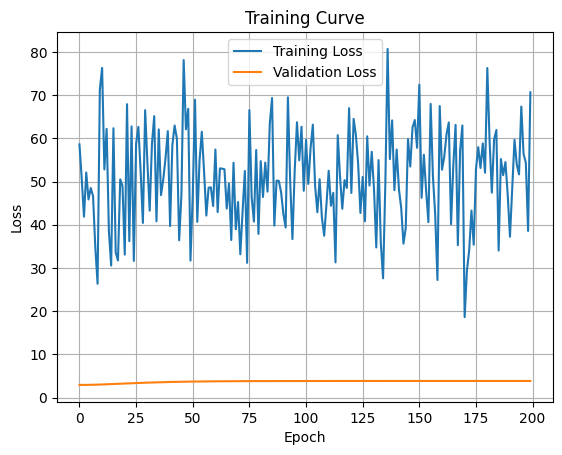

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train, label="Training Loss")
plt.plot(val, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()

C:\TEMP\ipykernel_18540\1551617623.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


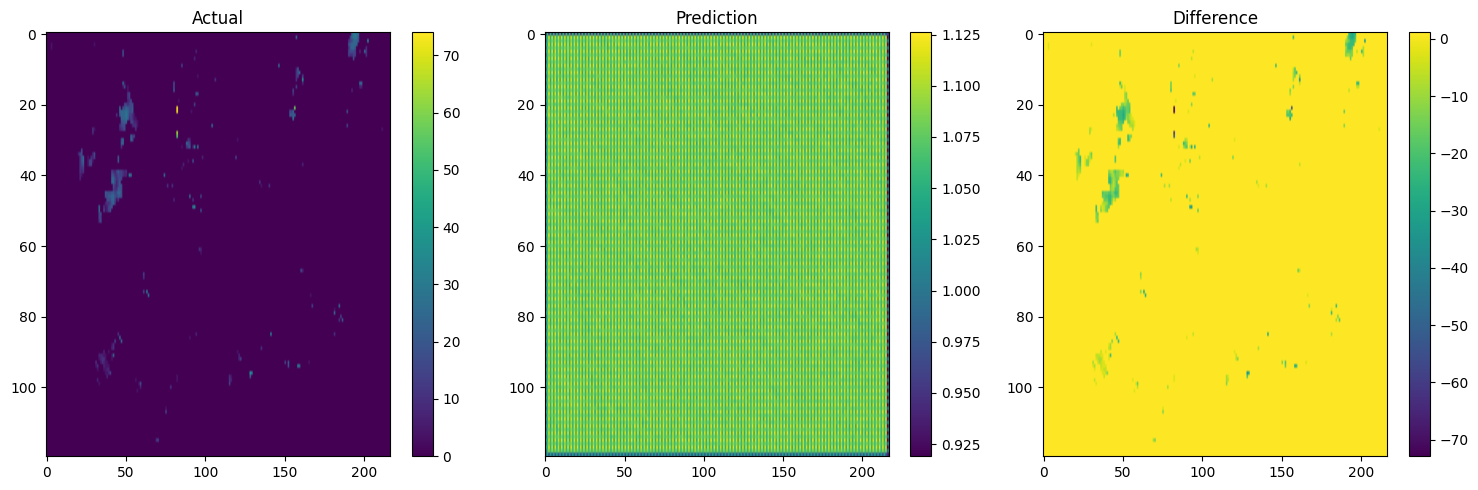

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

# get one batch
inputs, labels = next(iter(train_loader),3)

with torch.no_grad():
    outputs = model(inputs)
sample_no=6
# pick one sample from the batch
pred = outputs[sample_no]
actual = labels[sample_no]

# if shape is [1, H, W], remove the channel dimension
if pred.dim() == 3:
    pred = pred.squeeze(0)

if actual.dim() == 3:
    actual = actual.squeeze(0)

# move to cpu and convert to numpy
pred = pred.cpu().numpy()
actual = actual.cpu().numpy()

diff = pred - actual

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(actual, aspect='auto')
plt.title("Actual")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(pred, aspect='auto')
plt.title("Prediction")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(diff, aspect='auto')
plt.title("Difference")
plt.colorbar()

plt.tight_layout()
plt.show()